# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


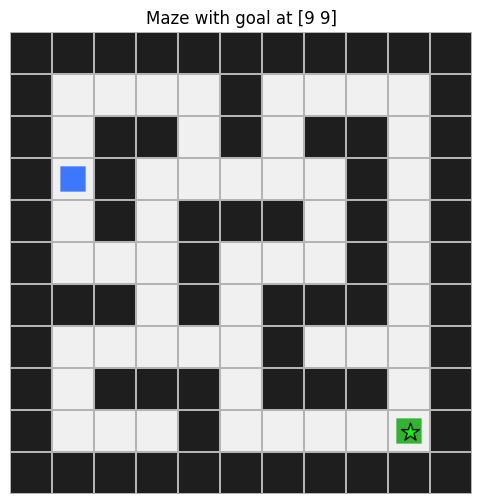

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

## Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(9, 9) -----

[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-49.913 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-37.213 | eval_len=375.5| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-49.913 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.962 | eval_return=-37.188 | eval_len=375.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.953 | eval_return=-43.463 | eval_len=438.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factor

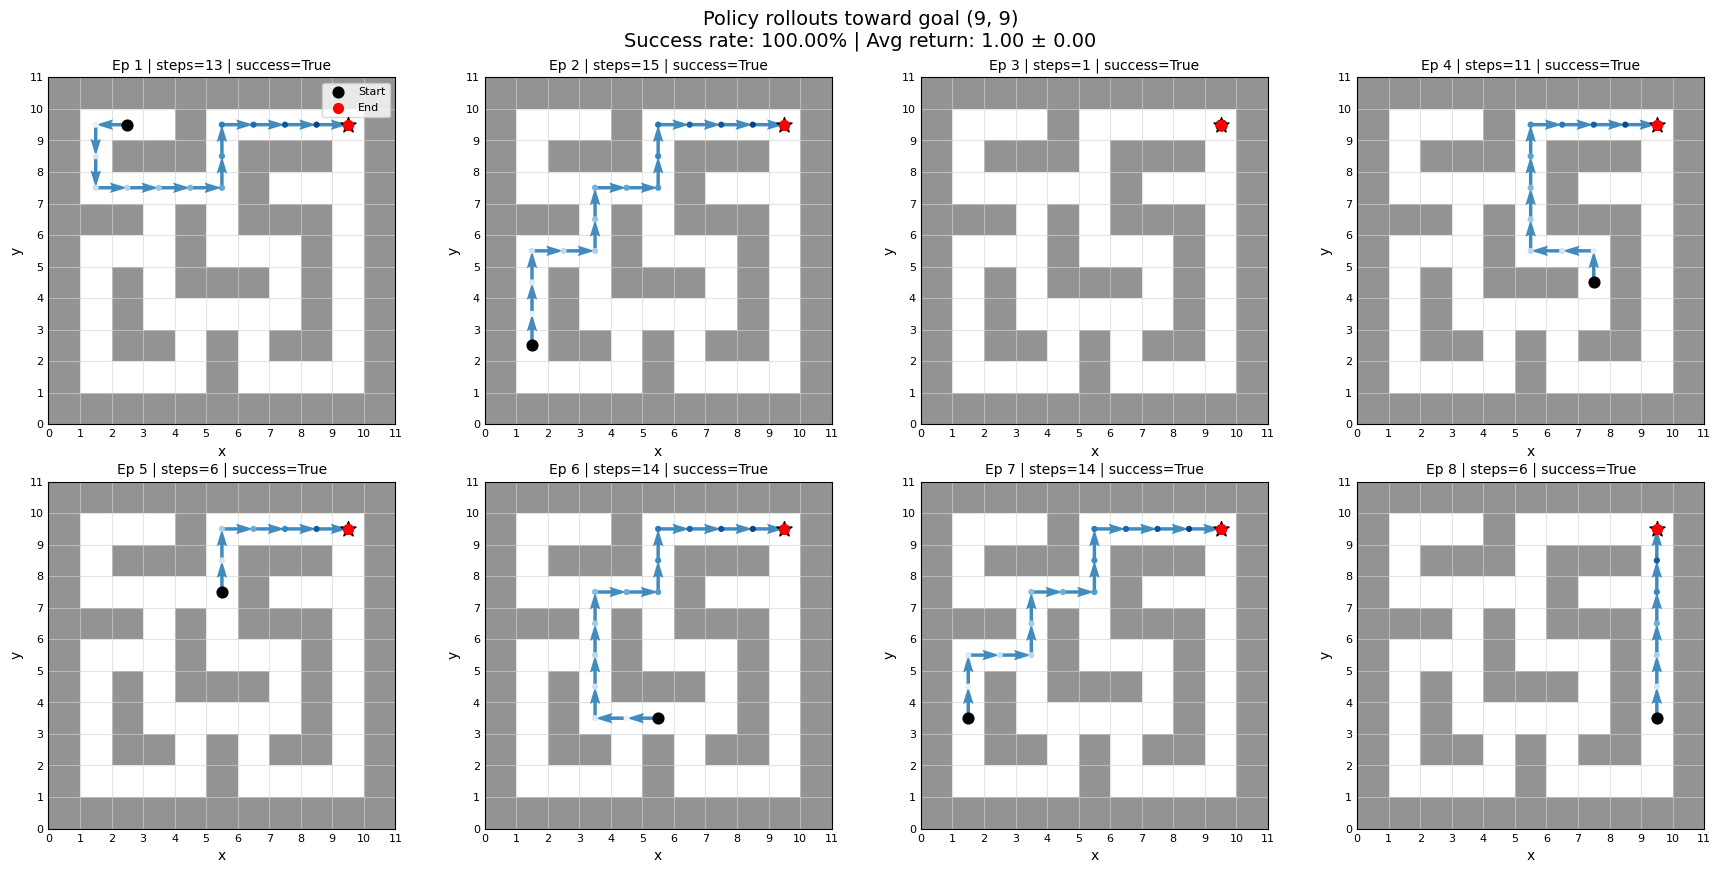

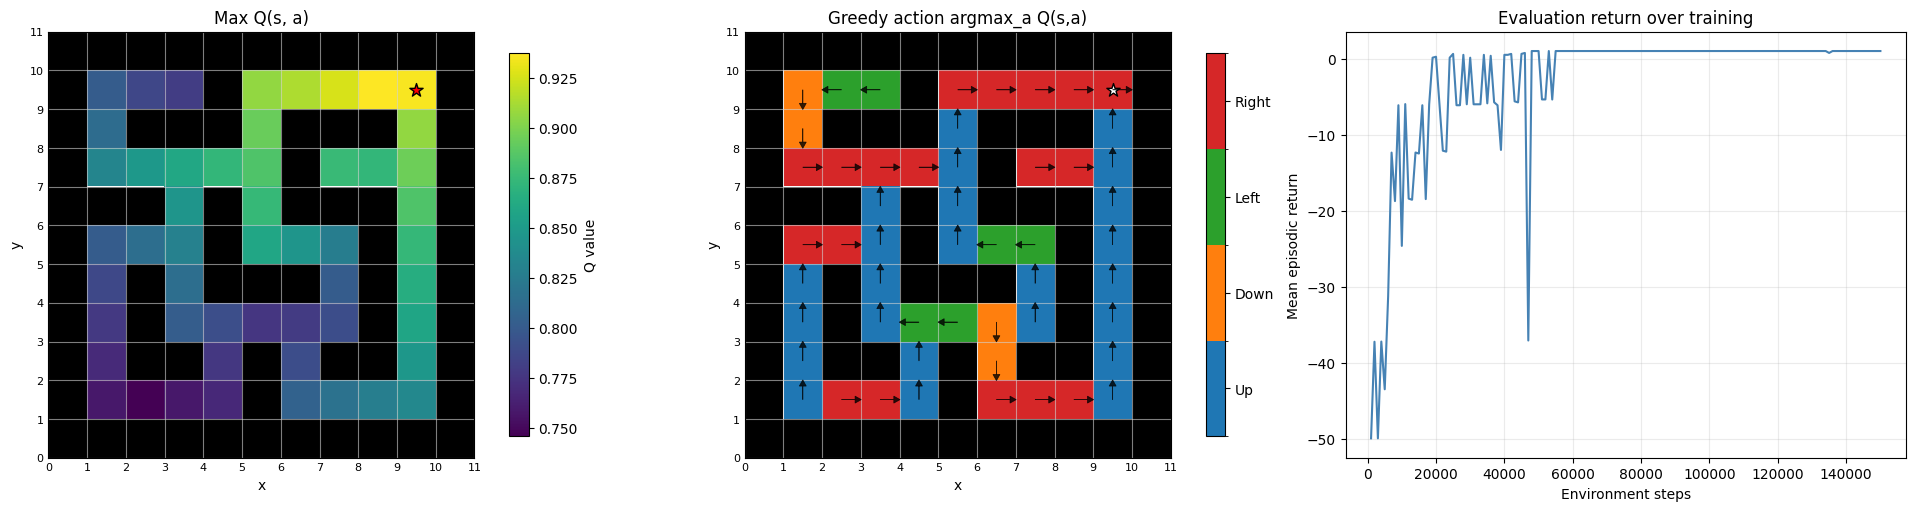

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.461095  3.238082  3.0191877 2.8952603 2.5892105]
cumulative variance (first 5 dims): [0.1433944  0.2689051  0.37802032 0.47836176 0.5586108 ]
cos(phi(s,a), psi): mean=0.7672, std=0.0740


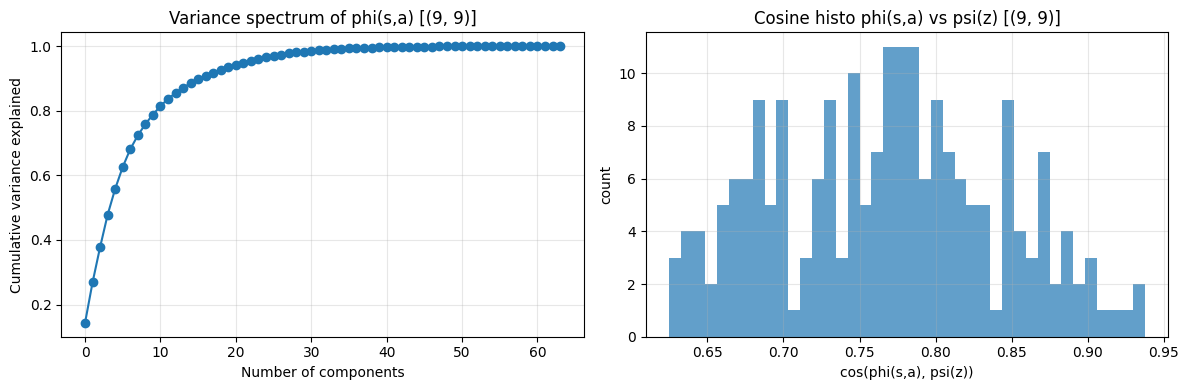


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 9.380961418151855

----- seed=42, goal=(7, 7) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-48.825 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-48.988 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-48.850 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   4000 | e

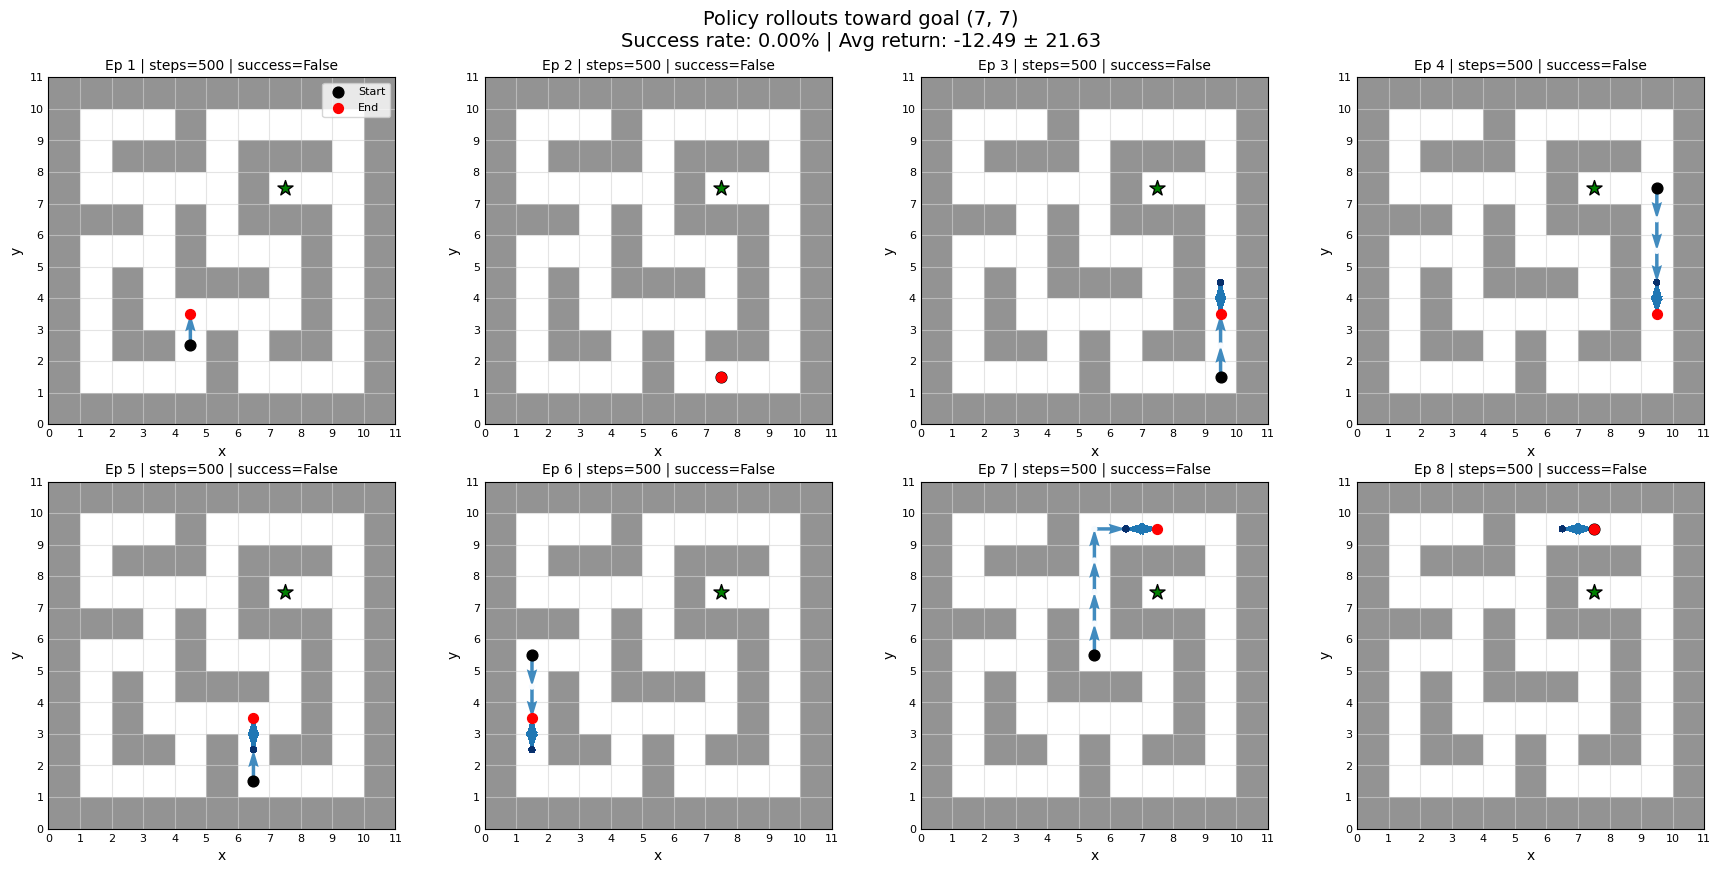

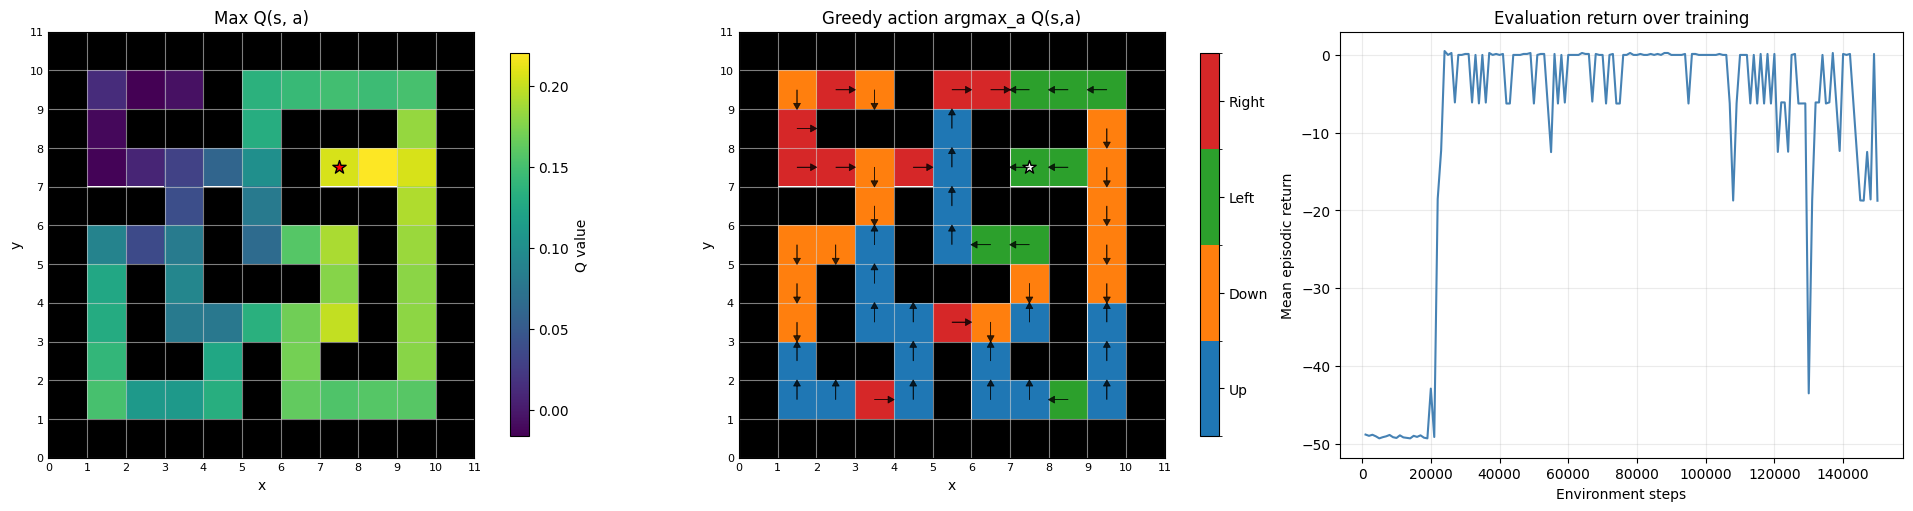

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.463495  3.2392027 3.0200953 2.896852  2.5898643]
cumulative variance (first 5 dims): [0.14347723 0.2689733  0.37806585 0.47843644 0.5586611 ]
cos(phi(s,a), psi): mean=0.0817, std=0.0676


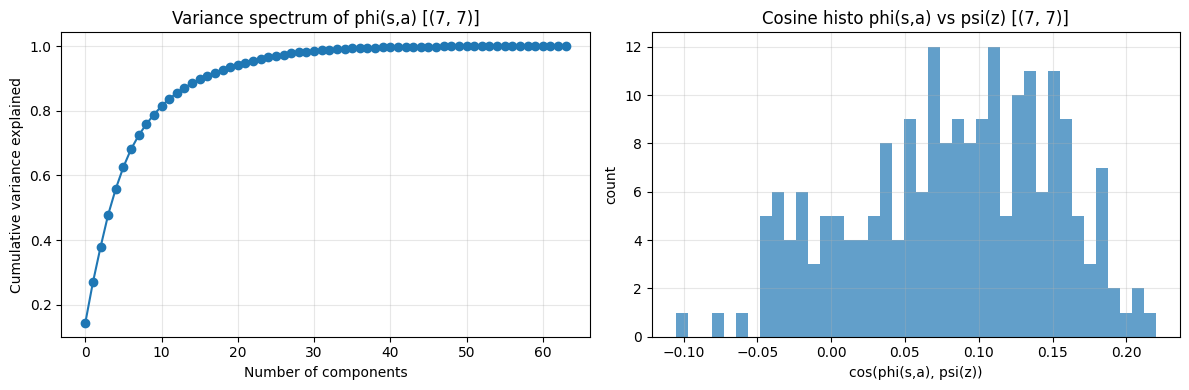


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)
  (9, 9)      1.000      0.114
  (7, 7)      0.114      1.000

Off-diagonal mean similarity: 0.114
Off-diagonal min similarity: 0.114
Off-diagonal max similarity: 0.114
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 7.842958450317383

----- seed=42, goal=(3, 5) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-12.375 | eval_len=438.2| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-12.363 | eval_len=438.2| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-12.200 | eval_len=375.9| Ortho loss=0.000 | SigReg l

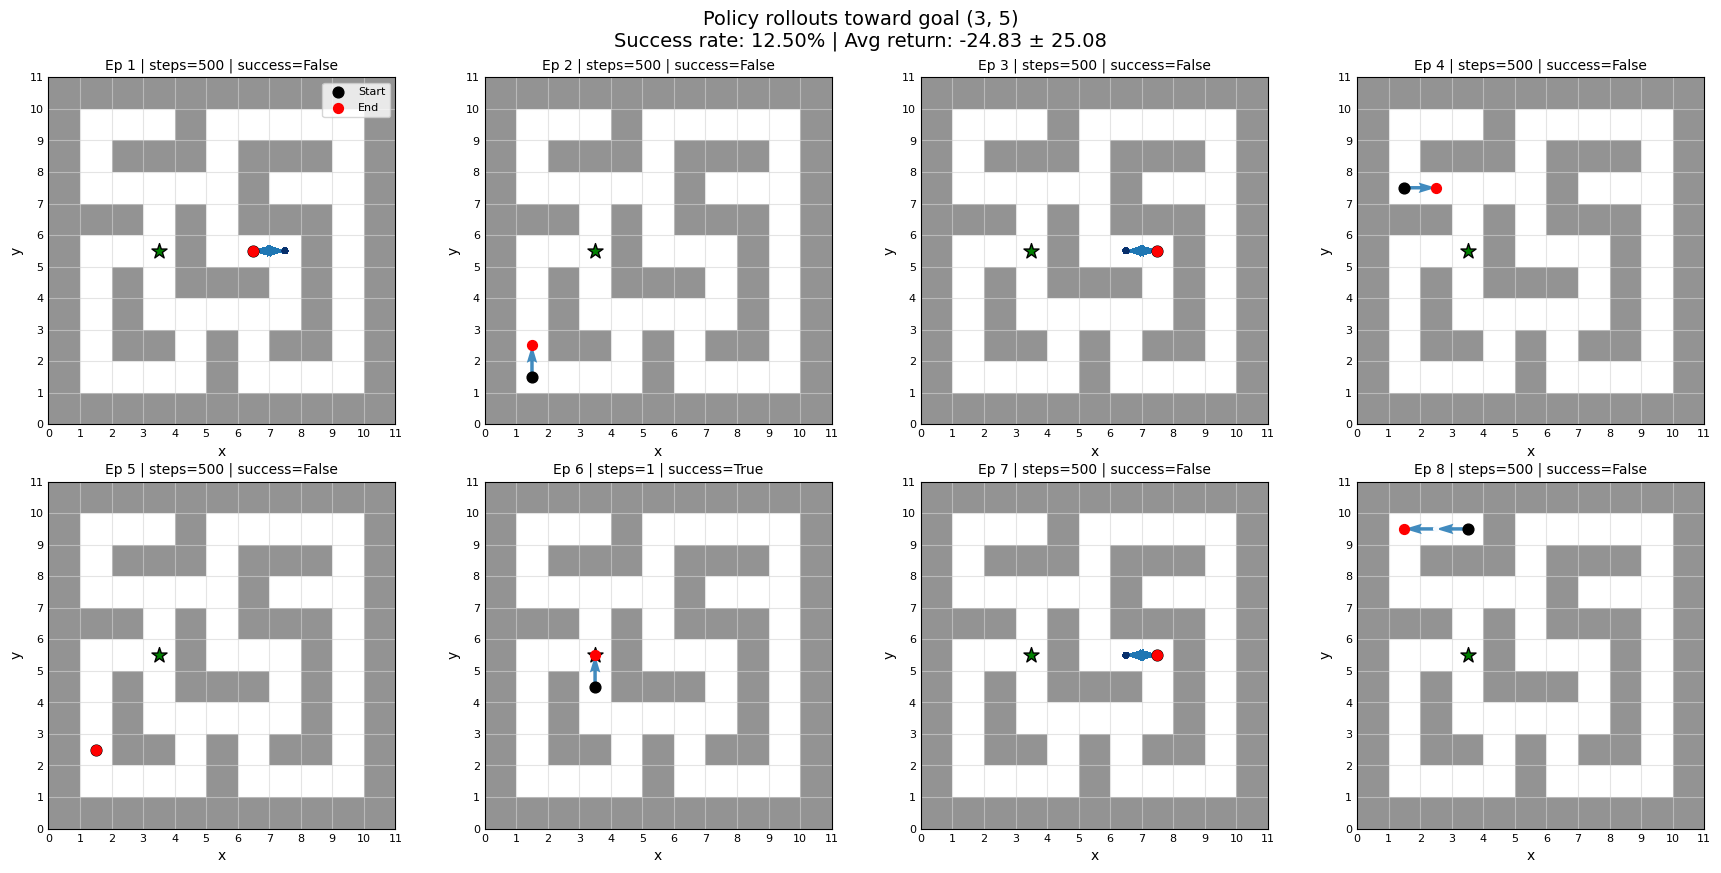

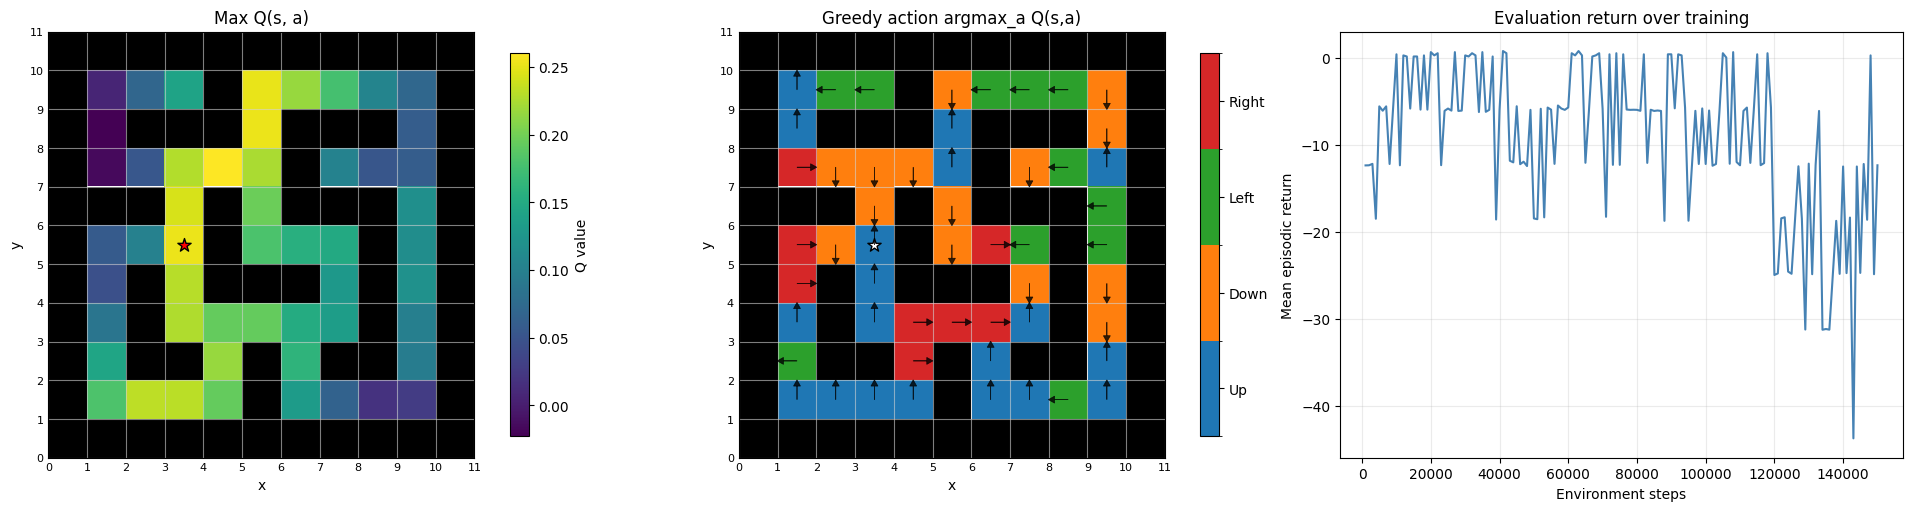

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4661381 3.241465  3.0212967 2.898564  2.5915058]
cumulative variance (first 5 dims): [0.14351566 0.26902914 0.37807128 0.47843423 0.5586597 ]
cos(phi(s,a), psi): mean=0.0986, std=0.0829


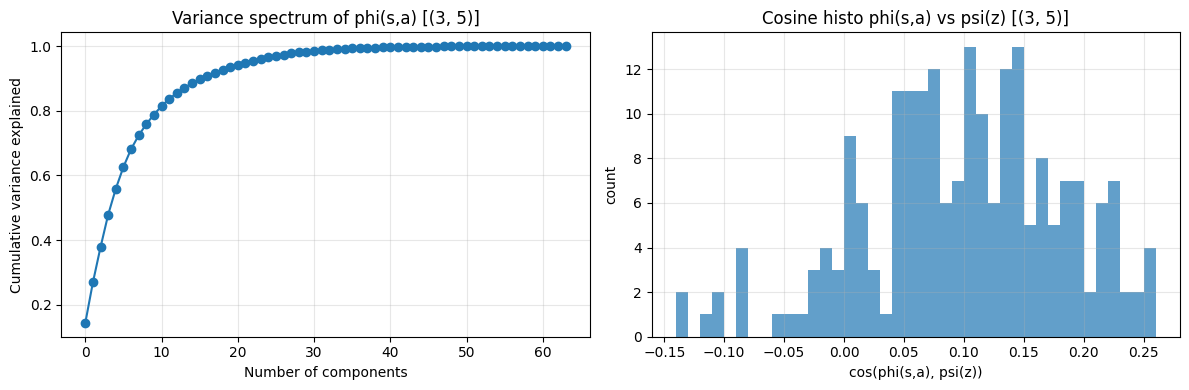


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.114      0.167
  (7, 7)      0.114      1.000      0.379
  (3, 5)      0.167      0.379      1.000

Off-diagonal mean similarity: 0.220
Off-diagonal min similarity: 0.114
Off-diagonal max similarity: 0.379
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 9.354778289794922

----- seed=42, goal=(3, 9) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-37.188 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-49.638 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | ep

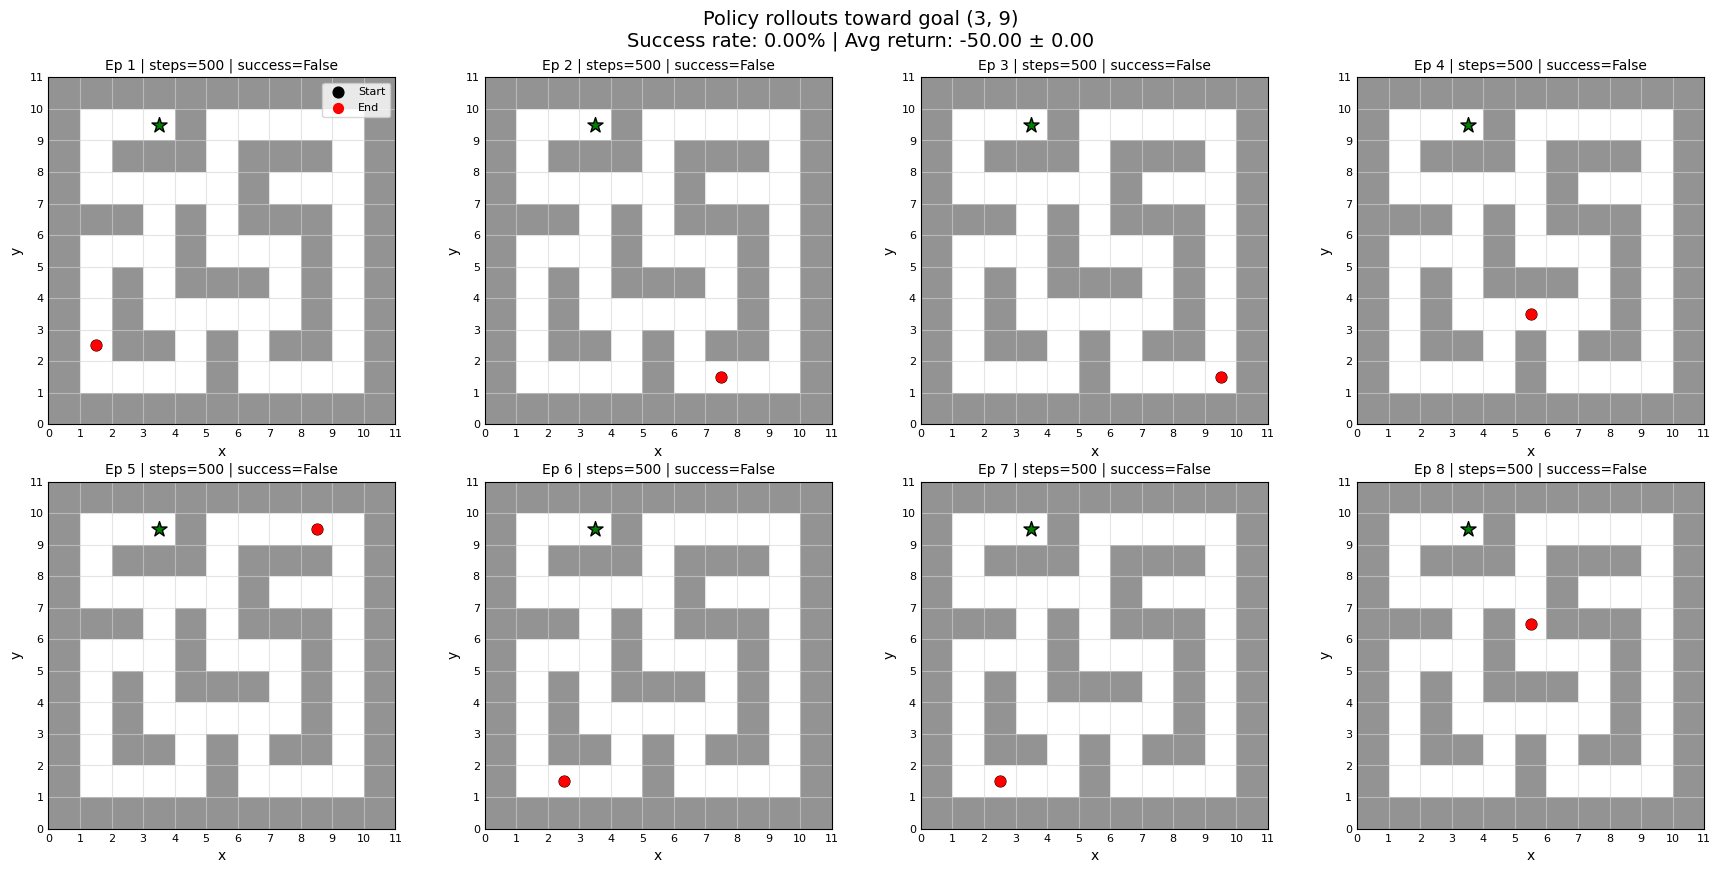

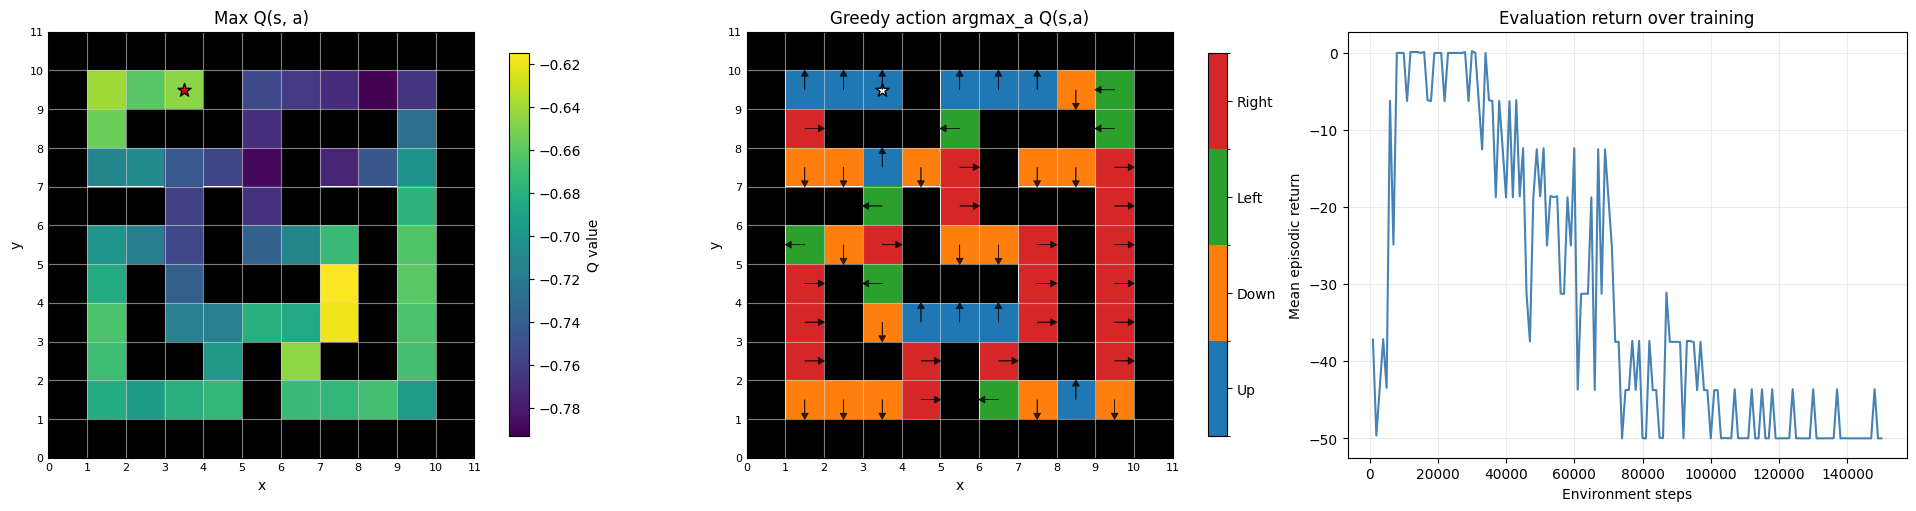

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4412985 3.2232735 3.008586  2.8810627 2.5791748]
cumulative variance (first 5 dims): [0.14309867 0.26863956 0.37801397 0.4783129  0.55869377]
cos(phi(s,a), psi): mean=-0.7599, std=0.0662


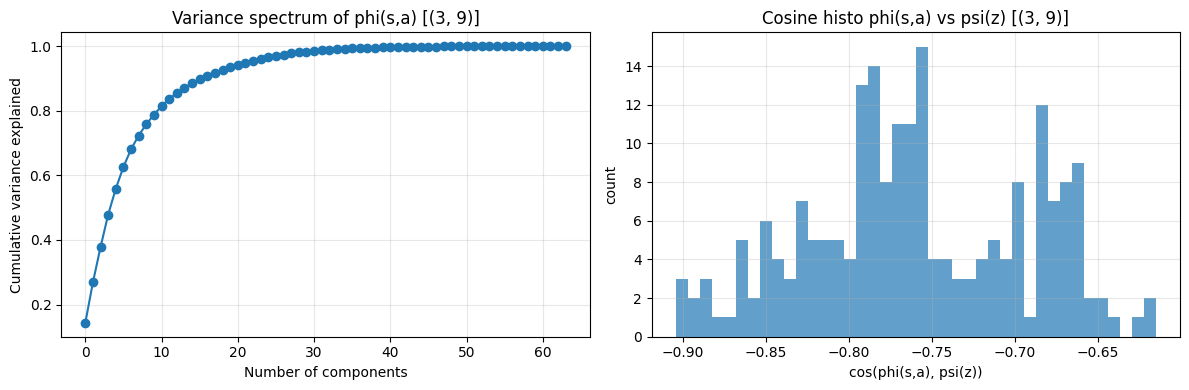


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.114      0.167     -0.975
  (7, 7)      0.114      1.000      0.379     -0.055
  (3, 5)      0.167      0.379      1.000     -0.149
  (3, 9)     -0.975     -0.055     -0.149      1.000

Off-diagonal mean similarity: -0.087
Off-diagonal min similarity: -0.975
Off-diagonal max similarity: 0.379
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 9.996194839477539

----- seed=42, goal=(5, 5) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-50.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-49.988 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.

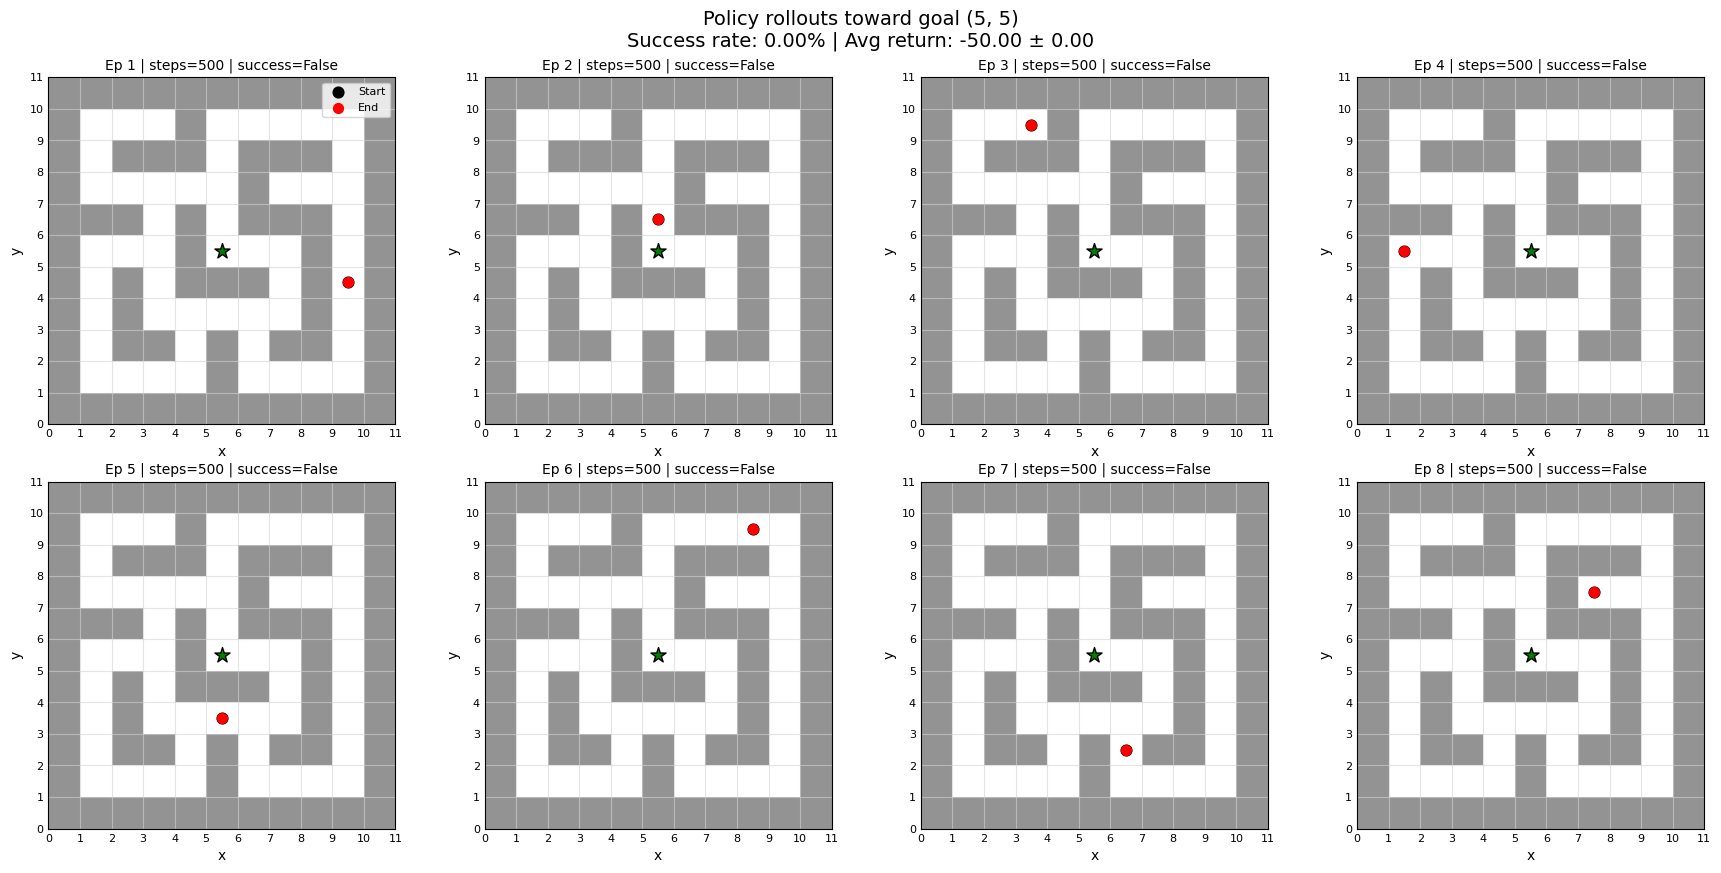

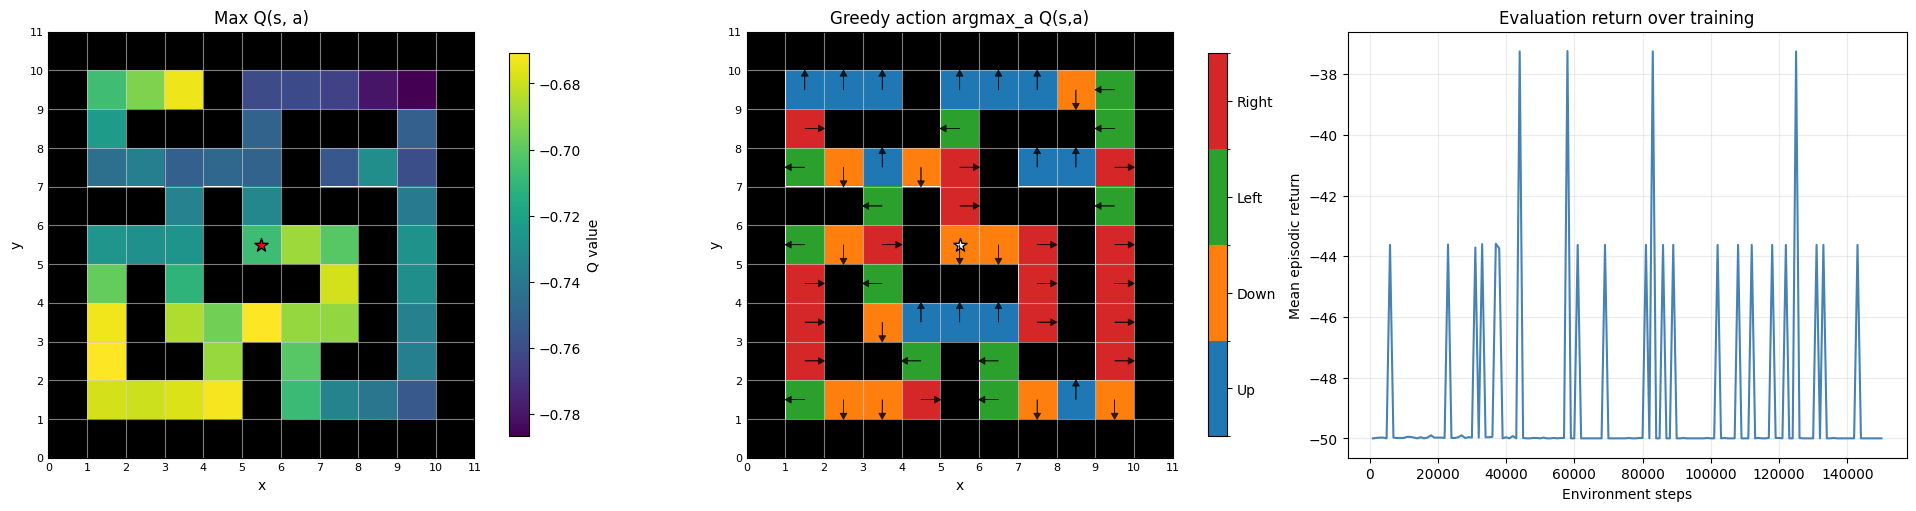

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4306643 3.2132103 3.0030787 2.872373  2.5737033]
cumulative variance (first 5 dims): [0.1429366  0.2683273  0.3778541  0.47805434 0.55850023]
cos(phi(s,a), psi): mean=-0.7737, std=0.0591


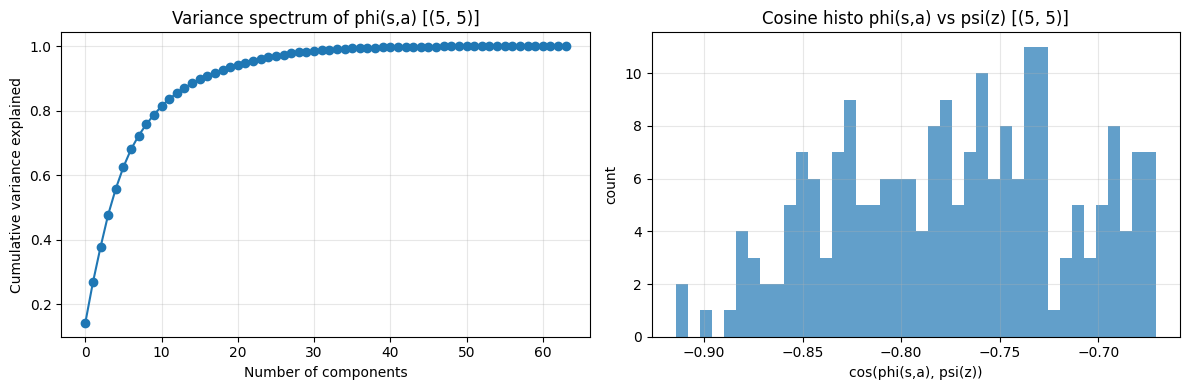


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.114      0.167     -0.975     -0.988
  (7, 7)      0.114      1.000      0.379     -0.055     -0.078
  (3, 5)      0.167      0.379      1.000     -0.149     -0.121
  (3, 9)     -0.975     -0.055     -0.149      1.000      0.981
  (5, 5)     -0.988     -0.078     -0.121      0.981      1.000

Off-diagonal mean similarity: -0.073
Off-diagonal min similarity: -0.988
Off-diagonal max similarity: 0.981
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 9.998640060424805


In [ ]:
SEEDS = [42]
GOALS = [(9, 9), (7, 7), (3, 5), (3, 9), (5, 5)]
BUFFER_CAPACITY = 100000
LR = float(1e-3)

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)  # your helper

    # Create env to get obs_dim, num_actions once
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # One network per seed, reused across goals
    q_net = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)
    q_target.load_state_dict(q_net.state_dict())
    for p in q_target.parameters():
        p.requires_grad_(False)

    base_goal_encoder_state = deepcopy(q_net.goal_encoder.state_dict())
    # base_obs_last_layer_state = deepcopy(q_net.obs_encoder[-1].state_dict())

    # Per-seed task embedding memory (for repulsion)
    seed_task_embedding_memory = []
    seen_goal_labels = []
    prev_reference_params = None
    prev_fisher_diag = None
    prev_goal = None
    prev_buffer = None


    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        # Resync target to current q_net before training on this goal
        q_target.load_state_dict(q_net.state_dict())
        for p in q_target.parameters():
            p.requires_grad_(False)

        # q_net.goal_encoder.load_state_dict(base_goal_encoder_state)
        # q_target.goal_encoder.load_state_dict(base_goal_encoder_state)

        # q_net.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)
        # q_target.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)

        # Decide which params to train (transfer vs. full)
        if goal_idx == 0:
            # First goal: train full network
            for p in q_net.parameters():
                p.requires_grad_(True)
            trainable_params = None  # let dqn_train create its usual optimizer
            regulariser = None
            reference_params = None
            fisher_diag = None
        else:

            for p in q_net.parameters():
                p.requires_grad_(True)
            # Subsequent goals: reuse phi, train only psi (and optionally last phi layer)
            # for p in q_net.sa_encoder.parameters():
            #     p.requires_grad_(False)
            # for p in q_net.goal_encoder.parameters():
            #     p.requires_grad_(True)

            # # If you want psi + last phi layer instead of only psi:
            # last_layer = list(q_net.sa_encoder.children())[-1]
            # for p in last_layer.parameters():
            #     p.requires_grad_(True)

            trainable_params = [p for p in q_net.parameters() if p.requires_grad]
            regulariser = "repulsion"  # or None if you don’t want repulsion here

        # Train on this goal, reusing q_net weights from previous goals
        (
        q_network,
        q_target_network,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
        )= dqn_train(
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            obs_dim=obs_dim,
            buffer_capacity=BUFFER_CAPACITY,
            lr=LR,
            goal=goal,
            device=DEVICE,
            embedding_memory=seed_task_embedding_memory,  # previous task embeddings in this seed
            regulariser=regulariser,
            reg_alpha=1,          # your choice 
            params=trainable_params, # None for full training, list for transfer mode
            reference_params=prev_reference_params,
            fisher_diag=prev_fisher_diag,
            sa_reg_prefix_filter="sa_encoder",
            make_env=make_env
        )
        visualise_q_table(goal, q_net, eval_returns=eval_returns, device=DEVICE, make_env=make_env)
        visualise_embeddings(goal, q_net, device=DEVICE, make_env=make_env)
        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

        prev_reference_params = snapshot_named_parameters(q_net, prefix_filter="sa_encoder")
        prev_fisher_diag = estimate_fisher_diag(
                model=q_net,
                target_model=q_target,
                replay_buffer=buffer,
                goal=goal,
                num_actions=num_actions,
                device=DEVICE,
                gamma=0.99,
                batch_size=256,
                n_batches=64,
                prefix_filter="sa_encoder"
        )

        ewc_param_count = sum(
            p.numel() for name, p in q_net.named_parameters()
            if name in prev_reference_params
        )
        total_param_count = sum(p.numel() for p in q_net.parameters())

        print("EWC params:", ewc_param_count, "Total params:", total_param_count)

        print("ref len:", len(prev_reference_params))
        if prev_fisher_diag is not None:
            print("fisher len:", len(prev_fisher_diag))
            some_key = next(iter(prev_fisher_diag.keys()))
            print("sample F value:", prev_fisher_diag[some_key].abs().mean().item())

        prev_goal = goal
        prev_buffer = buffer

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)

In [ ]:
goals = list(overall_results.keys())

min_steps_per_goal = []
min_time_per_goal = []
used_goals = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.array(steps_raw).flatten()
    time_arr  = np.array(time_raw).flatten()

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    min_steps_per_goal.append(steps_arr.min())
    min_time_per_goal.append(time_arr.min())
    used_goals.append(goal)

if not min_steps_per_goal:
    raise ValueError("No goals with non-empty min_steps/min_time found.")

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
line1 = ax1.plot(
    x, min_steps_per_goal,
    label="Min Steps",
    color="tab:blue",
    marker="o",
)
ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
line2 = ax2.plot(
    x, min_time_per_goal,
    label="Min Time",
    color="tab:orange",
    marker="o",
)
ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
plt.show()

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

(9, 9) cos(old, final) = -0.9881373047828674
(7, 7) cos(old, final) = -0.08761152625083923
(3, 5) cos(old, final) = -0.10386472940444946
(3, 9) cos(old, final) = 0.9960572123527527
(5, 5) cos(old, final) = 1.0
Episode 1: 15 steps | return: 1.00 | reached goal: True
Episode 2: 14 steps | return: 1.00 | reached goal: True
Episode 3: 15 steps | return: 1.00 | reached goal: True
Episode 4: 14 steps | return: 1.00 | reached goal: True
Episode 5: 15 steps | return: 1.00 | reached goal: True
Episode 6: 11 steps | return: 1.00 | reached goal: True
Episode 7: 11 steps | return: 1.00 | reached goal: True
Episode 8: 9 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


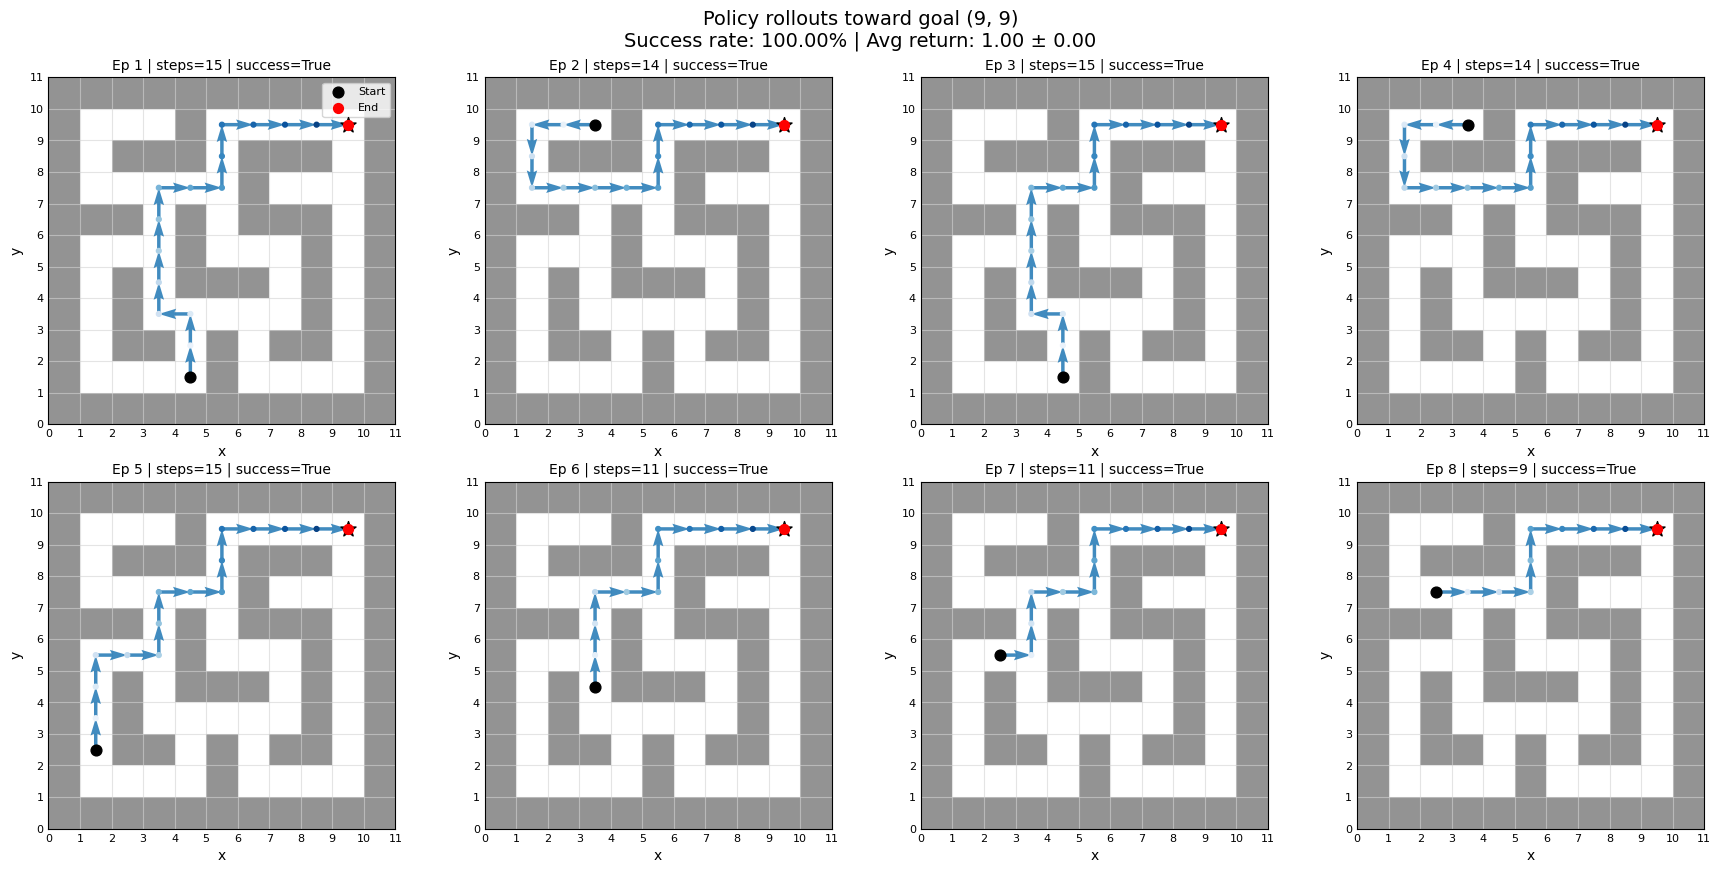

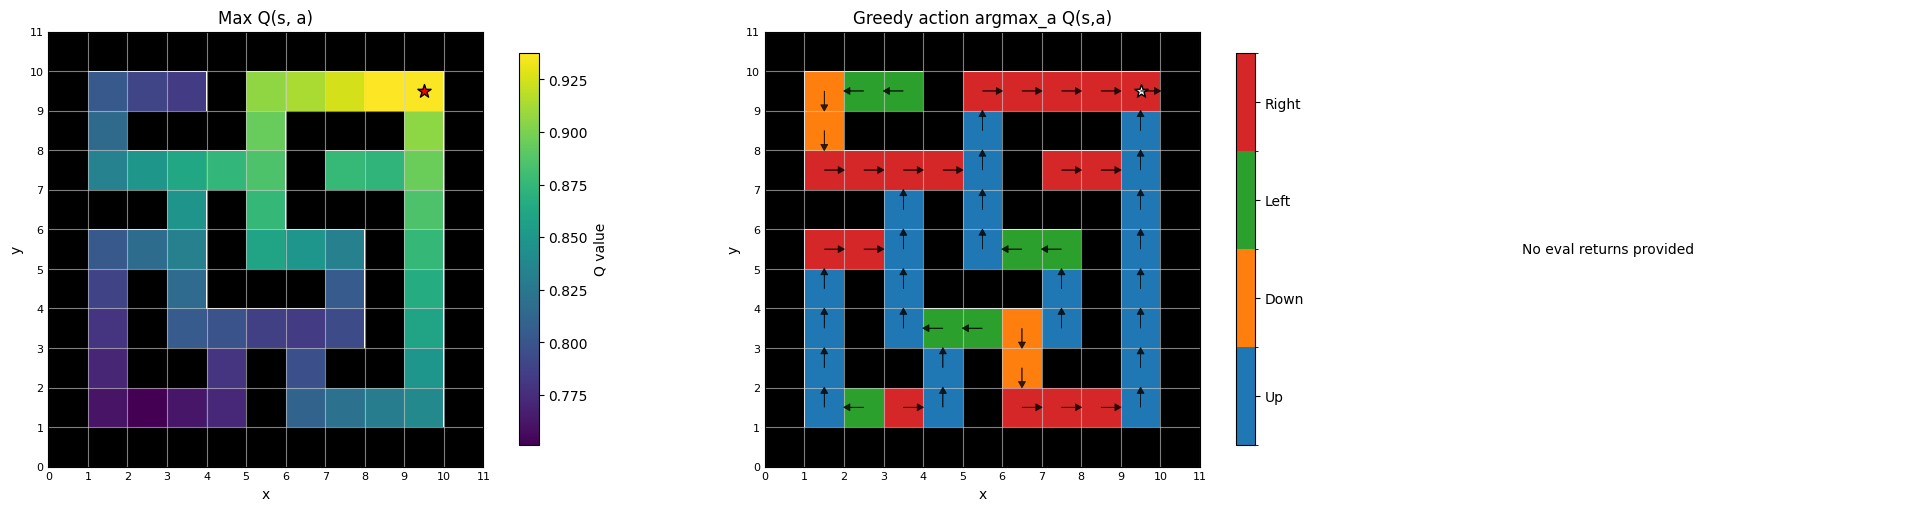

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4306643 3.2132103 3.0030787 2.872373  2.5737033]
cumulative variance (first 5 dims): [0.1429366  0.2683273  0.3778541  0.47805434 0.55850023]
cos(phi(s,a), psi): mean=-0.7723, std=0.0625


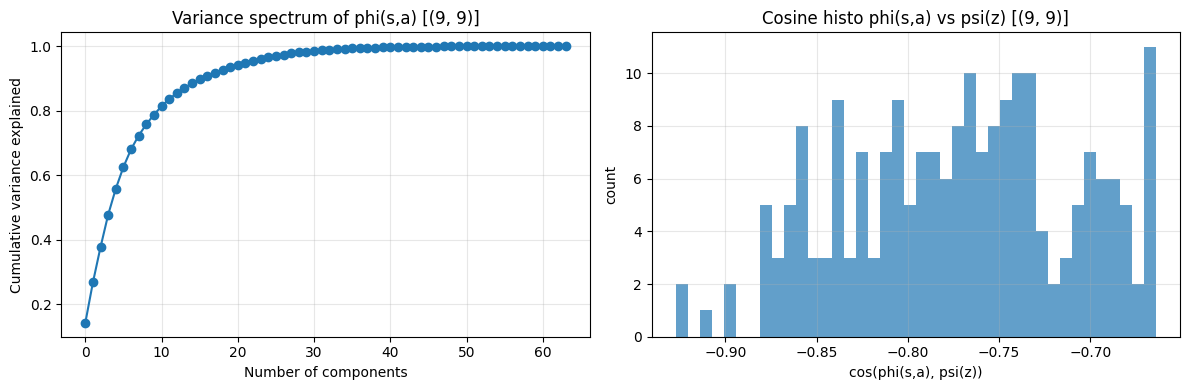

Goal (9, 8) not found in overall_results. Skipping visualization.
Episode 1: 500 steps | return: -50.00 | reached goal: False
Episode 2: 500 steps | return: -50.00 | reached goal: False
Episode 3: 500 steps | return: -50.00 | reached goal: False
Episode 4: 500 steps | return: -50.00 | reached goal: False
Episode 5: 500 steps | return: -50.00 | reached goal: False
Episode 6: 500 steps | return: -50.00 | reached goal: False
Episode 7: 500 steps | return: -50.00 | reached goal: False
Episode 8: 500 steps | return: -50.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: -50.00 ± 0.00


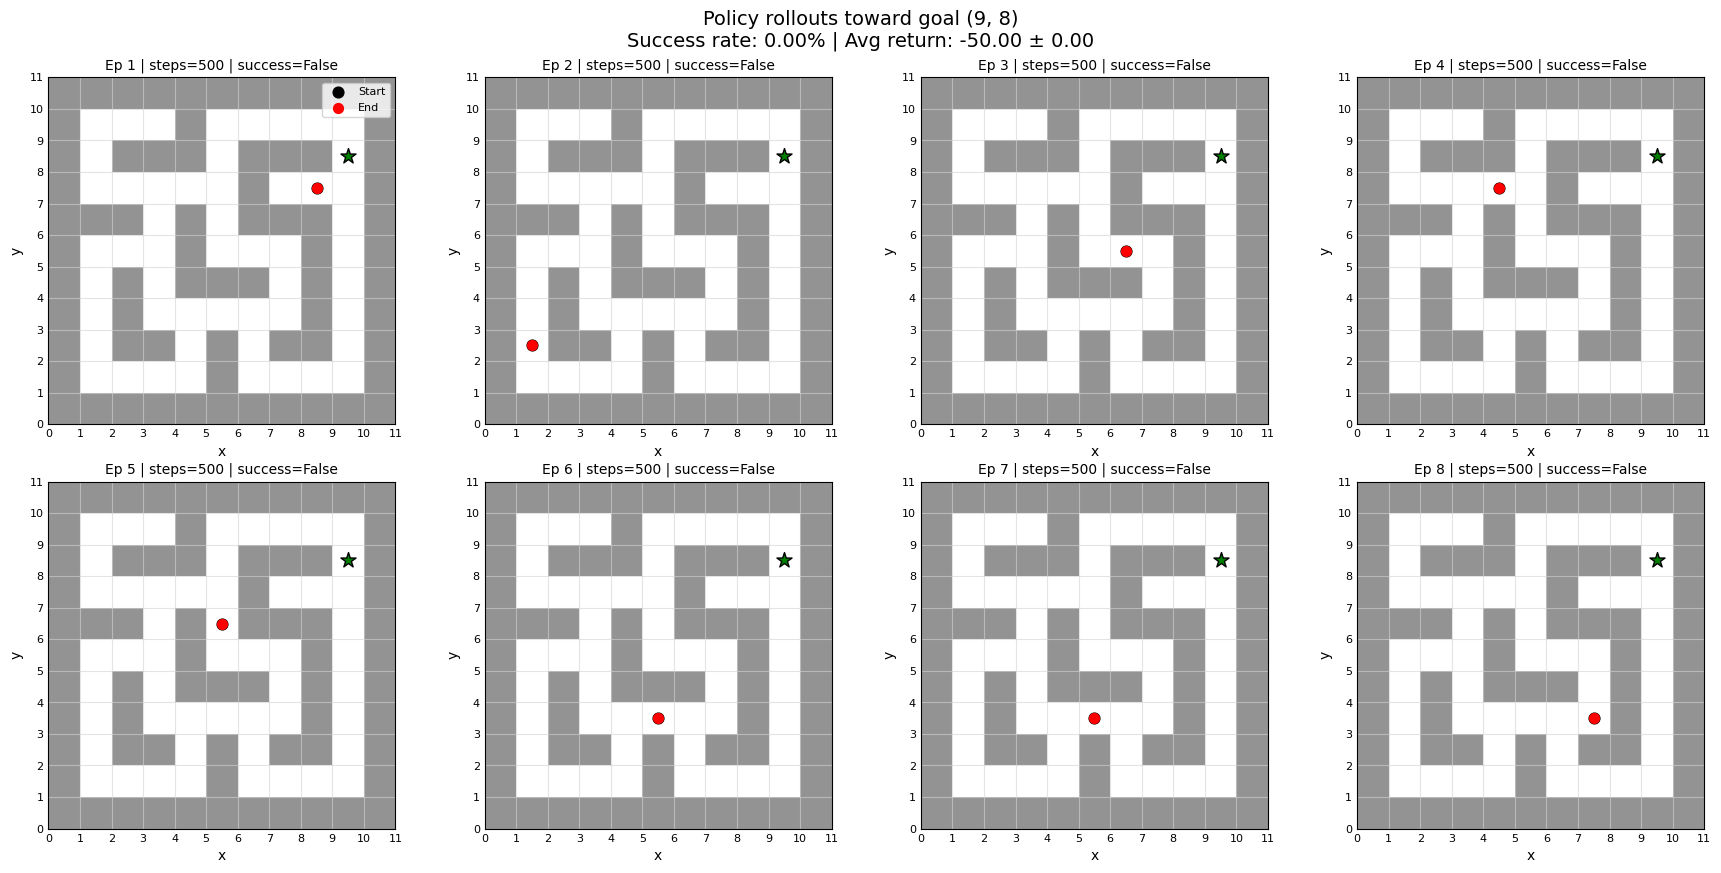

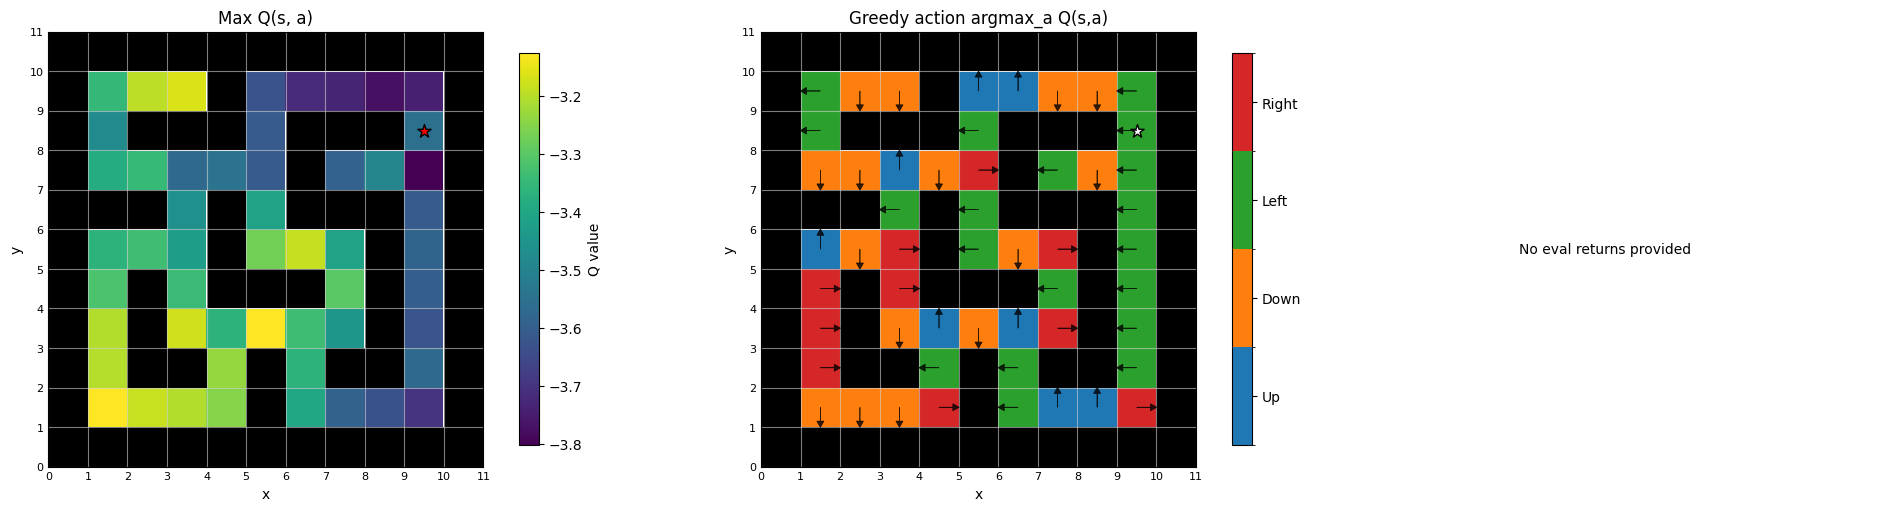

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4306643 3.2132103 3.0030787 2.872373  2.5737033]
cumulative variance (first 5 dims): [0.1429366  0.2683273  0.3778541  0.47805434 0.55850023]
cos(phi(s,a), psi): mean=-0.7665, std=0.0652


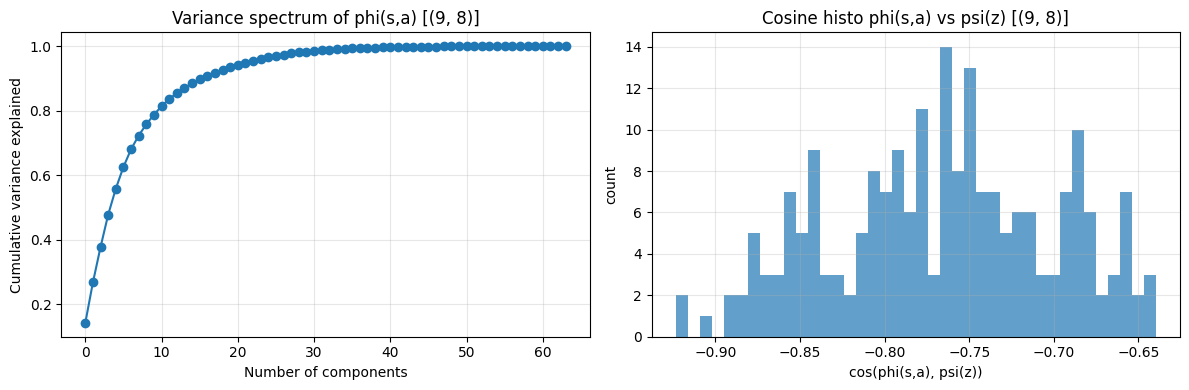

Goal (9, 7) not found in overall_results. Skipping visualization.
Episode 1: 500 steps | return: -50.00 | reached goal: False
Episode 2: 500 steps | return: -50.00 | reached goal: False
Episode 3: 500 steps | return: -50.00 | reached goal: False
Episode 4: 500 steps | return: -50.00 | reached goal: False
Episode 5: 500 steps | return: -50.00 | reached goal: False
Episode 6: 500 steps | return: -50.00 | reached goal: False
Episode 7: 500 steps | return: -50.00 | reached goal: False
Episode 8: 500 steps | return: -50.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: -50.00 ± 0.00


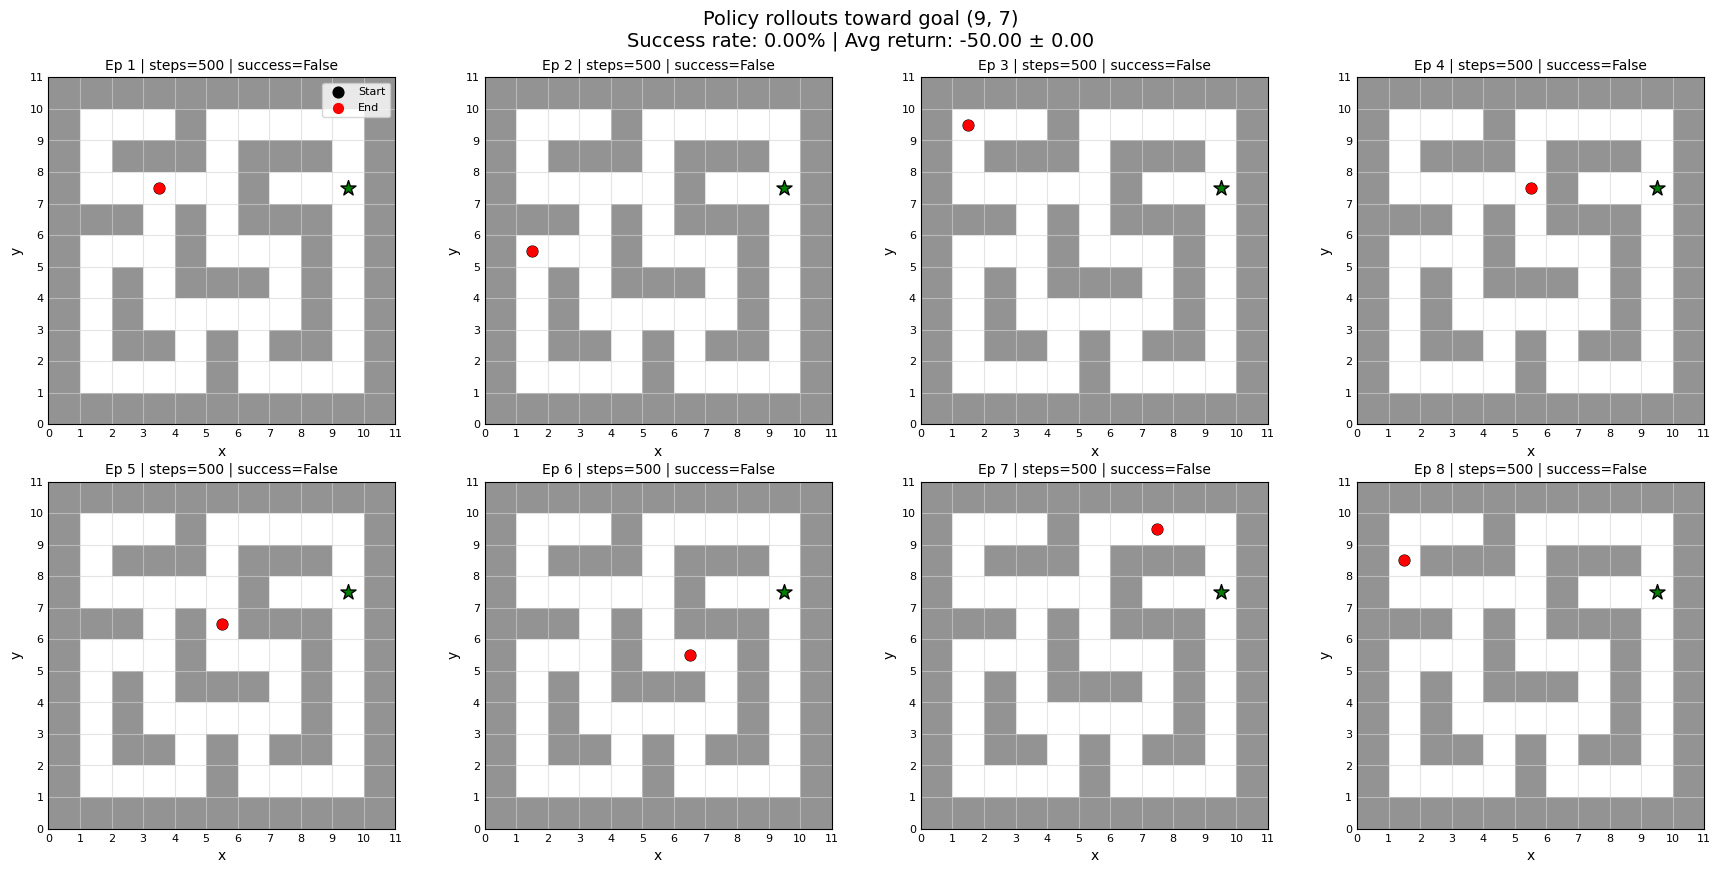

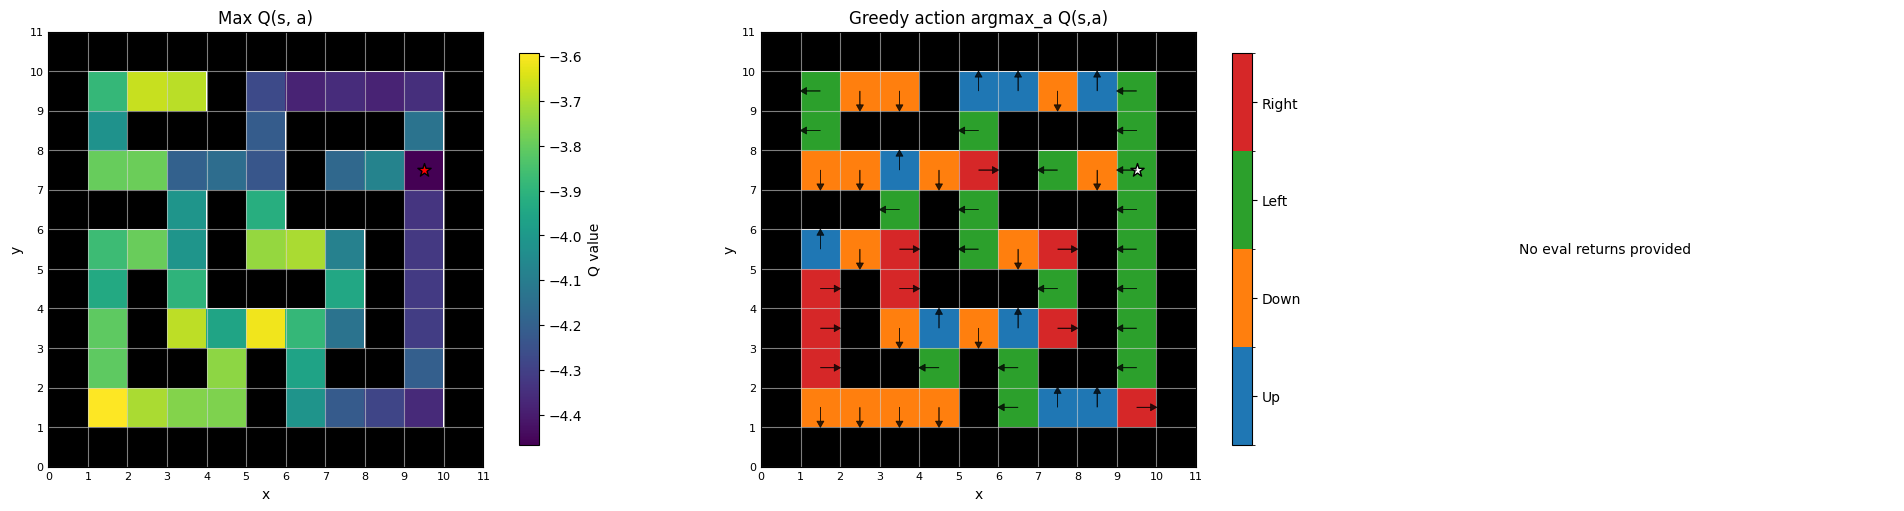

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4306643 3.2132103 3.0030787 2.872373  2.5737033]
cumulative variance (first 5 dims): [0.1429366  0.2683273  0.3778541  0.47805434 0.55850023]
cos(phi(s,a), psi): mean=-0.7536, std=0.0669


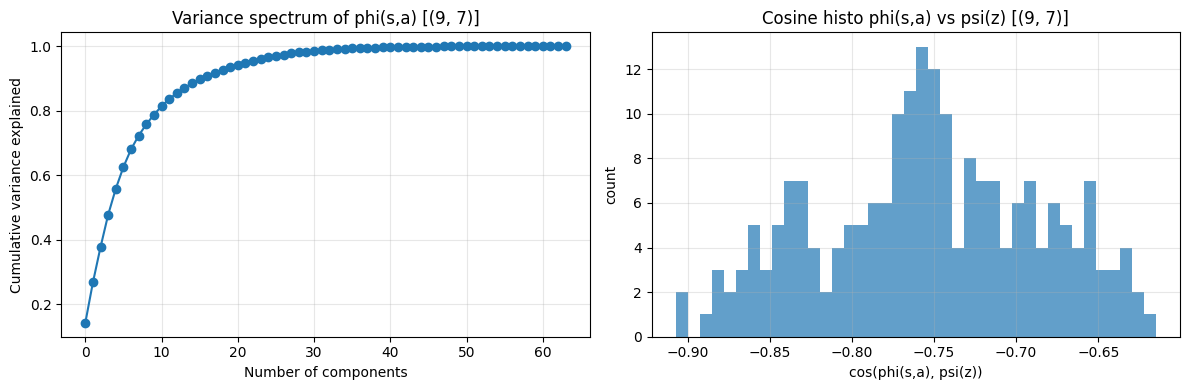

In [5]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_net, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        print(f"Goal {goal} not found in overall_results. Skipping visualization.")
        overall_results[goal] = {
            "eval_returns": [],
            "eval_returns_time": [],
            "min_steps": [],
            "min_time": [],
            "task_embeddings": [],
            "sa_embeddings": [],
            "sa_fixed_probe_embeddings": [],
            "sa_batches_final": [],
        }
        task_embedding = q_net.goal_encoder(torch.tensor(goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy()
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_net, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_net, device=DEVICE, make_env=make_env)

[WARN] Skipping goal (9, 8): empty min_steps or min_time
[WARN] Skipping goal (9, 7): empty min_steps or min_time


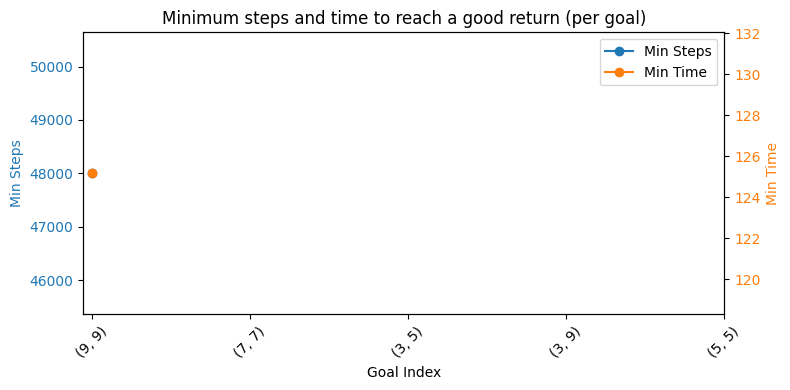

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_net,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])